In [2]:
!pip install scikit-learn pandas numpy
import pandas as pd
import numpy as np
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import confusion_matrix
from sklearn.metrics import f1_score
from sklearn.metrics import accuracy_score

In [3]:
df=pd.read_csv('C:\\Users\\HP\\Downloads\\diabetes.csv')

In [4]:
#replace 0 values with na then calculate mean then replace 0 with mean
zero_values=['Glucose','BloodPressure','SkinThickness','Insulin','BMI']
for column in zero_values:
  df[column]=df[column].replace(0,np.nan)
  mean=int(df[column].mean(skipna=True))
  df[column]=df[column].replace(np.nan,mean)

In [5]:
#splitting the dataset
x=df.drop(columns='Outcome')
y=df['Outcome']

In [6]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=0)

In [7]:
# Define parameter values to test
param_grid = {
'criterion': ['gini', 'entropy'],
'max_depth': [2,3,4,5,6,7],
'min_samples_split': [2,5,10],
'min_samples_leaf': [1,2,4]
}

# Create model
model = DecisionTreeClassifier()

# Grid Search
grid = GridSearchCV(model, param_grid, cv=5)

grid.fit(x_train, y_train)
print(f"Best Parameters for Diabetes: {grid.best_params_}")

Best Parameters for Diabetes: {'criterion': 'gini', 'max_depth': 2, 'min_samples_leaf': 1, 'min_samples_split': 2}


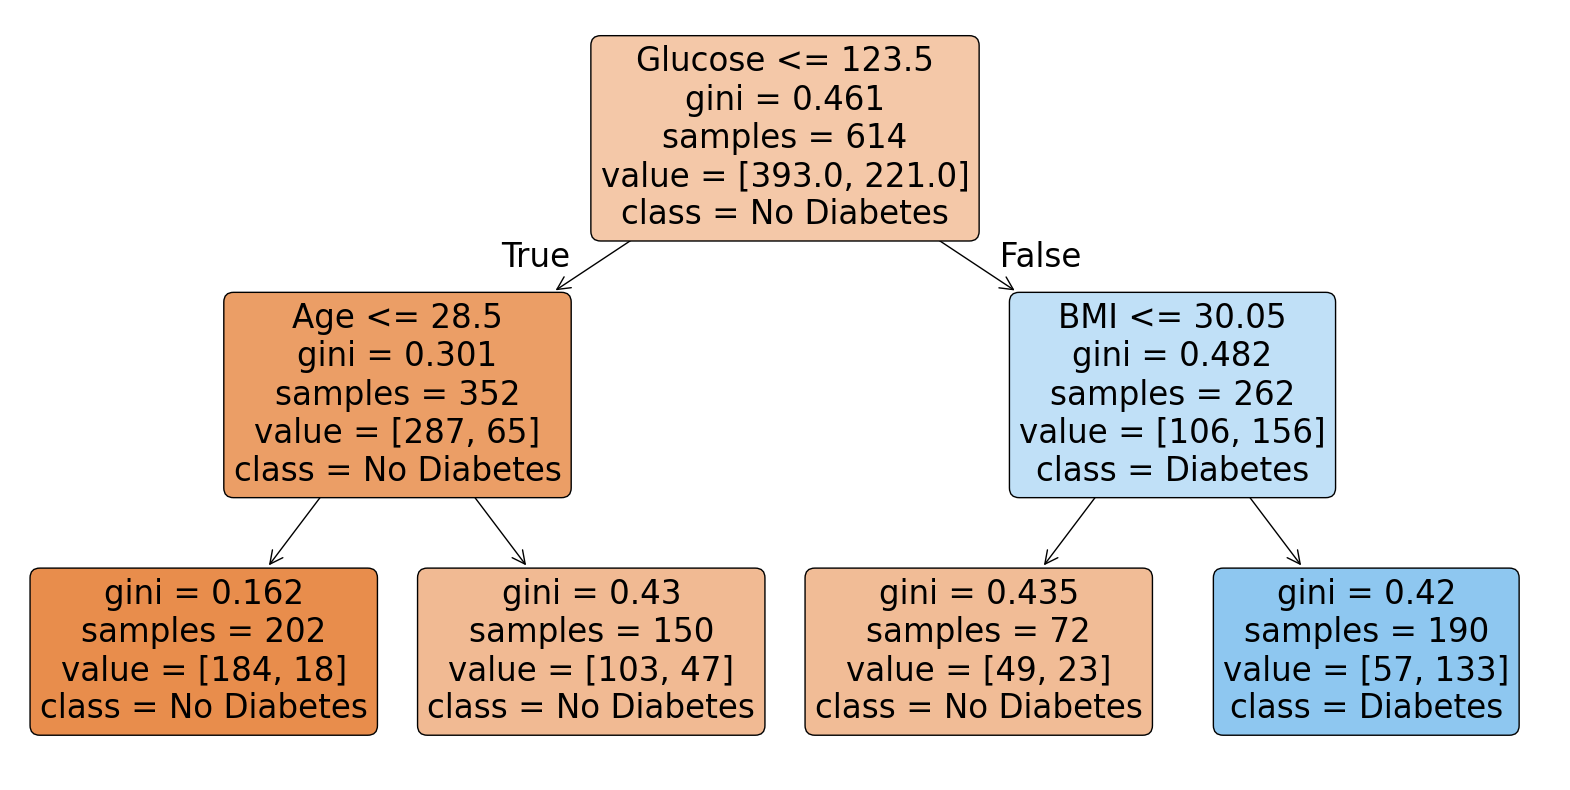

In [8]:
#plot tree
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

plt.figure(figsize=(20,10))
plot_tree(grid.best_estimator_,
          feature_names=x.columns,
          class_names=['No Diabetes', 'Diabetes'],
          filled=True,
          rounded=True)
plt.show()


In [9]:
# Train the model (using your optimized grid search result)
best_model = grid.best_estimator_
best_model.fit(x_train, y_train)

# Make predictions
y_pred = best_model.predict(x_test)
print(y_pred)

[1 0 0 0 0 0 1 1 0 0 1 1 0 0 0 0 1 0 0 0 1 0 0 0 0 1 0 1 0 0 0 0 0 0 0 1 0
 0 0 1 0 0 0 1 1 0 0 0 0 1 0 0 1 1 0 0 0 0 0 0 1 1 0 1 1 0 1 0 0 0 0 0 0 1
 1 1 0 0 0 0 0 1 0 0 0 0 0 0 1 0 0 0 0 0 1 0 0 1 0 0 0 0 0 0 1 0 0 1 0 0 0
 0 1 1 1 1 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 1 0 0 0 0 0 0 0 1 0 0 0 0 0 0
 0 0 0 1 0 0]


In [10]:
#evaluate model
cm=confusion_matrix(y_test,y_pred)
print(cm)
print(f1_score(y_test,y_pred))
print(accuracy_score(y_test,y_pred))

[[93 14]
 [23 24]]
0.5647058823529412
0.7597402597402597


In [11]:
#recall score is important in healthcare domain
from sklearn.metrics import recall_score

# Calculate recall
recall = recall_score(y_test, y_pred)

print(f"Recall Score: {recall:.2f}")

Recall Score: 0.51
